# Module 2: Static Charts in Python & R

**Unit A · Week 2** · Track 2 — Visualization, Analytic Hubs & Responsible AI

Translating a Module 1 chart-type decision into working code, applied to the Chapter 3 dataset, with a reusable house-style function and one small-multiples figure.

## Learning objectives

- **Intermediate** _Apply_ — Build publication-quality static charts with a consistent, reusable house style.
- **Intermediate** _Apply_ — Apply Module 1 principles to a real regional dataset: correct chart type, honest scale, accessible color.

## Setup

This notebook reads `../../data/processed/track2_dataset.csv`, built by
`data/make_sample_data.py`. It is **synthetic** data shaped like the real
NISR/HDX handoff described in the course site's Chapter 3 — swap in a real
extract by re-pointing the path below once you have one. See
`data/README.md` for where to get real data and exactly what to rename.


In [1]:
import pandas as pd

DATA_PATH = "../../data/raw/synthetic_eicv_extract.csv"
df = pd.read_csv(DATA_PATH, parse_dates=["date"])
print(f"{len(df):,} rows · {df['district'].nunique()} districts · "
      f"{df['date'].min().date()} to {df['date'].max().date()}")
df.head()

240 rows · 10 districts · 2023-01-01 to 2024-12-01


,date,province,district,district_pcode,indicator,value,feature_1,feature_2,outcome
0,2023-01-01,Kigali City,Gasabo,SIM-GAS,sample_wellbeing_index,39.37,82.01,19.22,1
1,2023-02-01,Kigali City,Gasabo,SIM-GAS,sample_wellbeing_index,45.24,49.99,17.62,1
2,2023-03-01,Kigali City,Gasabo,SIM-GAS,sample_wellbeing_index,41.16,46.66,19.93,0
3,2023-04-01,Kigali City,Gasabo,SIM-GAS,sample_wellbeing_index,42.91,49.17,20.35,0
4,2023-05-01,Kigali City,Gasabo,SIM-GAS,sample_wellbeing_index,42.05,51.04,20.35,0


In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

def house_style(ax, title):
    ax.set_title(title, fontsize=13, fontweight="bold")
    sns.despine(ax=ax)
    ax.grid(axis="y", alpha=0.3)
    return ax

by_district = df.groupby("district", as_index=False)["value"].mean().sort_values("value")

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=by_district, x="value", y="district", ax=ax, color="#1D6E73")
house_style(ax, "Mean Value by District")
plt.tight_layout()
plt.show()

NameError: name 'df' is not defined

### Small multiples

One distribution panel per province — the same house style, faceted.

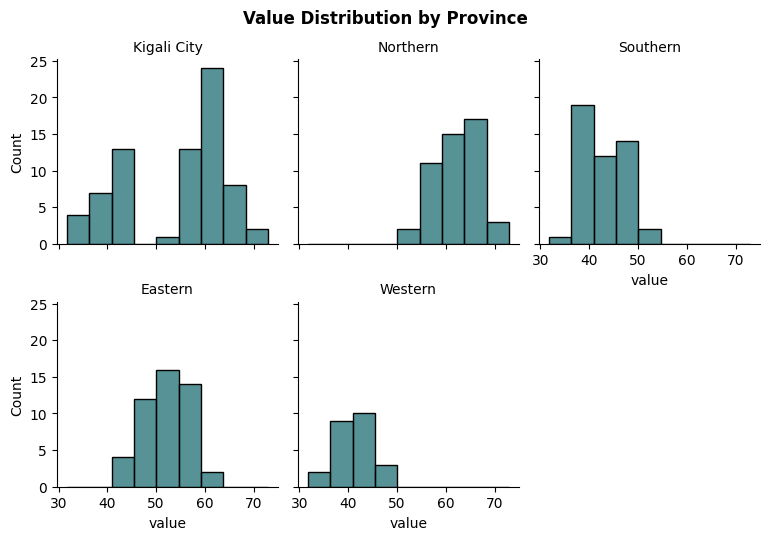

In [3]:
g = sns.displot(
    df, x="value", col="province", col_wrap=3, height=2.6, color="#1D6E73"
)
g.set_titles("{col_name}")
g.figure.suptitle("Value Distribution by Province", y=1.03, fontweight="bold")
plt.show()

## Your turn

Recreate the same set of five charts from the dataset in both matplotlib/seaborn and ggplot2, each wrapped in a reusable house-style theme function. Two are built below; add three more (a line chart of the national trend, a boxplot of value by province, and a small-multiples grid by district).

**Formative assessment.** Hands-on scripted exercise, graded submission: house-style function plus five charts in both languages, checklist-graded.

**Peer review.** Design-checklist review of a classmate's chart set, using the same checklist a facilitator would grade against.